### Basic chatbot with langgraph

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class state(TypedDict):
    #we use add messages after the every result the message is updated rather than
    messages:Annotated[list,add_messages]

In [3]:
import os
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [4]:
llm = ChatGroq(model = "qwen/qwen3-32b")

In [5]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000243B9E1B110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000243B9E1BB10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
def chatbot(state:state):
    return{"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(state)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##compile
graph = graph_builder.compile()

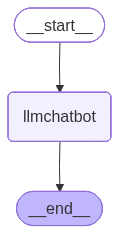

In [8]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"Hi"})


In [10]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [11]:
for event in graph.stream({"messages":"Hi,How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?


### Tool

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [33]:
def multiply(a:int,b:int)->int:
    """Multiply a and b 
    
    Args:
        a (int):first int
        b (int):second int
        
    Returns:
        int:output int
    """
    return a*b 

In [34]:
tools=[tool,multiply]

In [35]:
llm_with_tools = llm.bind_tools(tools)

In [36]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000243B9E1B110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000243B9E1BB10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for 

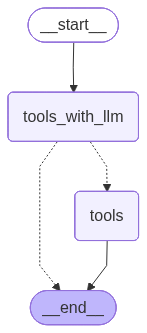

In [17]:
##State graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tools_with_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
#Node
builder = StateGraph(state)
builder.add_node("tools_with_llm",tools_with_llm)
builder.add_node("tools",ToolNode(tools))

#edge
builder.add_edge(START,"tools_with_llm")
builder.add_conditional_edges("tools_with_llm",tools_condition)
builder.add_edge("tools",END)

##compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"Current Ai news?"})
response

{'messages': [HumanMessage(content='Current Ai news?', additional_kwargs={}, response_metadata={}, id='b4c90284-c1aa-419f-9be9-34d8bd276292'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6ge3tgvyh', 'function': {'arguments': '{"query":"Current AI news","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1749, 'total_tokens': 1780, 'completion_time': 0.099265405, 'completion_tokens_details': None, 'prompt_time': 0.090772164, 'prompt_tokens_details': None, 'queue_time': 0.054685637, 'total_time': 0.190037569}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb9fb-4fa7-7f93-80ec-bf6d78a1a85a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Current AI news', 'search_depth': 'advanced', 'topi

In [20]:
response["messages"][-1].content

'{"query": "Current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://michaelparekh.substack.com/p/ai-kudos-to-3-ai-arbiters-on-against", "title": "AI: Kudos to 3 AI Arbiters on ‘Against the Grain’ Calls. ARD #91 - AI: Reset to Zero", "score": 0.6786044, "published_date": "Fri, 05 Jun 2026 16:46:24 GMT", "content": "### MP’s IPO / Elon / Anthropomorphizing backcat\\n\\n AI-RTZ #1066 — Elon’s Boundless AI Ambitions (SpaceX/xAI IPO filing outlines)\\n ARD #81 — Mega-AI IPOs Start to File While the Irons Are Hot\\n AI-RTZ #936 — Race for AI Data Centers in Space\\n AI-RTZ #974 — Elon’s SpaceX Prepping for 2026\\n AI-RTZ #510 — Tesla’s ‘Robotaxi & Robots’ Ride\\n AI-RTZ Oct 2023 — Bumpier Roads for Self-Driving Cars\\n AI-RTZ Sep 2023 — Don’t Anthropomorphize the AIs\\n AI-RTZ #809 — The Accelerating Costs of ‘Humanizing’ AI\\n AI-RTZ #630 — Making AI Look Like It’s ‘Thinking’\\n AI-RTZ Dec 2023 — On the Shoulders of Giants (OTSOG)\\n AI-RTZ 

In [21]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Current Ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6ge3tgvyh)
 Call ID: 6ge3tgvyh
  Args:
    query: Current AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://michaelparekh.substack.com/p/ai-kudos-to-3-ai-arbiters-on-against", "title": "AI: Kudos to 3 AI Arbiters on ‘Against the Grain’ Calls. ARD #91 - AI: Reset to Zero", "score": 0.6786044, "published_date": "Fri, 05 Jun 2026 16:46:24 GMT", "content": "### MP’s IPO / Elon / Anthropomorphizing backcat\n\n AI-RTZ #1066 — Elon’s Boundless AI Ambitions (SpaceX/xAI IPO filing outlines)\n ARD #81 — Mega-AI IPOs Start to File While the Irons Are Hot\n AI-RTZ #936 — Race 

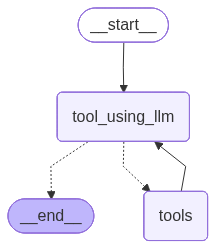

In [37]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_using_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
##Nodes
builder = StateGraph(state)
builder.add_node("tool_using_llm",tool_using_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_using_llm")
builder.add_conditional_edges("tool_using_llm",tools_condition)
builder.add_edge("tools","tool_using_llm")

##compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response = graph.invoke({"messages":"What are the frameworks of AI currently working?"})
response

{'messages': [HumanMessage(content='What are the frameworks of AI currently working?', additional_kwargs={}, response_metadata={}, id='d4d6e966-3877-4af3-8132-9a0687d6bb32'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jqdcbwpmp', 'function': {'arguments': '{"query":"current AI frameworks","search_depth":"advanced","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1754, 'total_tokens': 1785, 'completion_time': 0.117415788, 'completion_tokens_details': None, 'prompt_time': 0.093553591, 'prompt_tokens_details': None, 'queue_time': 0.054537731, 'total_time': 0.210969379}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb9ff-bc88-7961-adc3-8ed534499eaa-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI

In [26]:
response["messages"][-1].content

'The current AI frameworks working include:\n\n1. Hugging Face\n2. IBM Watson Studio\n3. Keras\n4. LangChain\n5. PyTorch\n6. Scikit-learn\n7. TensorFlow\n\nThese frameworks are used for building and deploying machine learning models, and they offer a range of features and tools to support AI development. Additionally, there are risk management frameworks for AI, such as the NIST AI risk management framework (AI RMF) and ISO/IEC 42001, which emphasize incorporating trustworthiness into the design, development, and evaluation of AI products, services, and systems.'

In [27]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the frameworks of AI currently working?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jqdcbwpmp)
 Call ID: jqdcbwpmp
  Args:
    query: current AI frameworks
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current AI frameworks", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/topics/ai-frameworks", "title": "What Are AI Frameworks? | IBM", "content": "### Performance and scalability\n\nHigh performance and scalability are vital, especially for AI systems handling huge data volumes or requiring real-time responses. These systems can benefit from frameworks with optimization features and distributed training functionalities.\n\n## Top AI frameworks\n\nFrameworks contin

In [39]:
response = graph.invoke({"messages":"What are the frameworks of AI currently working and then multiply 5 by 20?"})

In [40]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the frameworks of AI currently working and then multiply 5 by 20?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (a8ky7j14q)
 Call ID: a8ky7j14q
  Args:
    query: AI frameworks currently working
    search_depth: advanced
    topic: general
  multiply (bk4w8w5g1)
 Call ID: bk4w8w5g1
  Args:
    a: 5
    b: 20
================================= Tool Message =================================
Name: tavily_search

{"query": "AI frameworks currently working", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/topics/ai-frameworks", "title": "What Are AI Frameworks? | IBM", "content": "### Performance and scalability\n\nHigh performance and scalability are vital, especially for AI systems handling huge data volumes or requiring real-time responses. These systems can benefit from framewor

### MEMORY

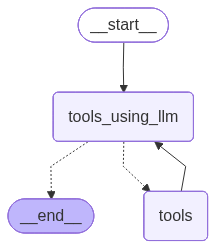

In [42]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tools_using_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Nodes
builder = StateGraph(state)
builder.add_node("tools_using_llm",tools_using_llm)
builder.add_node("tools",ToolNode(tools))

#edge
builder.add_edge(START,"tools_using_llm")
builder.add_conditional_edges("tools_using_llm",tools_condition)
builder.add_edge("tools","tools_using_llm")

##compile
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
config = {"configurable":{"thread_id":"1"}}
print(type(config))

<class 'dict'>


In [55]:
response = graph.invoke({"messages":" Hi My Name is Keerthi Vardhan Naidu"},config=config)
response

{'messages': [HumanMessage(content='My Name is Keerthi Vardhan Naidu', additional_kwargs={}, response_metadata={}, id='116a91e5-7e9d-4888-a4ab-c20fe15a0edd'),
  AIMessage(content="Hello Keerthi Vardhan Naidu! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 1757, 'total_tokens': 1791, 'completion_time': 0.119331868, 'completion_tokens_details': None, 'prompt_time': 0.198225656, 'prompt_tokens_details': None, 'queue_time': 0.05324424, 'total_time': 0.317557524}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eba14-e31b-7eb1-b2eb-efb01bfd75a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1757, 'output_tokens': 34, 'total_tokens': 1791}),
  HumanMessage(content='My Name is Keert

In [56]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My Name is Keerthi Vardhan Naidu
================================== Ai Message ==================================

Hello Keerthi Vardhan Naidu! It's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

My Name is Keerthi Vardhan Naidu
================================ Human Message =================================

 Hi My Name is Keerthi Vardhan Naidu
================================== Ai Message ==================================

Hi Keerthi Vardhan Naidu, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [57]:
response = graph.invoke({"messages":" Hey do you remember my name"},config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My Name is Keerthi Vardhan Naidu
================================== Ai Message ==================================

Hello Keerthi Vardhan Naidu! It's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

My Name is Keerthi Vardhan Naidu
================================ Human Message =================================

 Hi My Name is Keerthi Vardhan Naidu
================================== Ai Message ==================================

Hi Keerthi Vardhan Naidu, it's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

 Hey do you remember my name
================================== Ai Message ==================================

Yes, I remember your name. You are Keerthi Vardhan Naidu.


In [58]:
print(response["messages"][-1].content)

Yes, I remember your name. You are Keerthi Vardhan Naidu.


### STREAMING

In [59]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [60]:
def superbot(state:state):
    return {"messages":[llm.invoke(state["messages"])]}

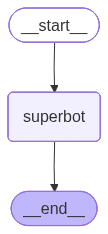

In [61]:
builder = StateGraph(state)

builder.add_node("superbot",superbot)
builder.add_edge(START,"superbot")
builder.add_edge("superbot",END)

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
config = {"configurable":{"thread_id":"1"}}
for chunk in graph.stream({"messages":"Hi my name Keerthi Vardhan I like Cricket"},config=config,stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="Nice to meet you, Keerthi Vardhan. Cricket is an exciting sport, and I'm sure you must be enjoying the thrill of the game. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 48, 'total_tokens': 116, 'completion_time': 0.172940078, 'completion_tokens_details': None, 'prompt_time': 0.002208733, 'prompt_tokens_details': None, 'queue_time': 0.320973054, 'total_time': 0.175148811}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eba31-9ae9-7253-8bb2-c3771a67797e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 68, 'total_tokens': 116})]}}


In [63]:
config = {"configurable":{"thread_id":"1"}}
for chunk in graph.stream({"messages":"Hi my name Keerthi Vardhan I like Cricket"},config=config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Hi my name Keerthi Vardhan I like Cricket', additional_kwargs={}, response_metadata={}, id='bc23cb3d-00e4-4e0d-9534-ea09da56904c'), AIMessage(content="Nice to meet you, Keerthi Vardhan. Cricket is an exciting sport, and I'm sure you must be enjoying the thrill of the game. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 48, 'total_tokens': 116, 'completion_time': 0.172940078, 'completion_tokens_details': None, 'prompt_time': 0.002208733, 'prompt_tokens_details': None, 'queue_time': 0.320973054, 'total_time': 0.175148811}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eba31-9ae9-7253-8bb2-c3771a67797e-0', tool_calls=[], invalid_to

In [65]:
config = {"configurable":{"thread_id":"3"}}
for chunk in graph.stream({"messages":"Hi my name Keerthi Vardhan I like football"},config=config,stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="Nice to meet you again, Keerthi Vardhan. It seems like you have a change of heart, from cricket to football. That's completely fine, football is an amazing sport as well. Which football team or player is your favorite? Are you a fan of the English Premier League, La Liga, or maybe the Indian Super League?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 121, 'total_tokens': 193, 'completion_time': 0.191192344, 'completion_tokens_details': None, 'prompt_time': 0.012056346, 'prompt_tokens_details': None, 'queue_time': 0.366611351, 'total_time': 0.20324869}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eba34-4bf9-71e3-aab0-3e3c0ad518ba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 121, 'output_tokens': 72, 'total_token

In [66]:
config = {"configurable":{"thread_id":"3"}}
async for event in graph.astream_events({"messages":"Hi do you remember me"},config=config,stream_mode="updates"):
    print(event)


{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi do you remember me'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eba34-bb32-7520-95f8-3b93acea1b27', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name Keerthi Vardhan I like Cricket', additional_kwargs={}, response_metadata={}, id='0bb8737f-9019-4846-a0bb-80db93811f89'), AIMessage(content="Nice to meet you, Keerthi Vardhan. Cricket is an exciting sport, and it's great that you're a fan. Which team or player is your favorite? Are you more into international cricket, IPL, or domestic cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 48, 'total_tokens': 99, 'completion_time': 0.171360428, 'completion_tokens_details': None, 'prompt_time': 0.002283722, 'prompt_tokens_details': None, 'queue_time': 0.077659543, 'total_time': 0.17364415}, 'model_